<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/LR_SharedBikes/LR_SharedBikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importing all required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#  importing the "drive" module from the "google.colab" library, facilitating access to Google Drive within a Colab notebook.
from google.colab import drive

In [5]:
# mounting the user's Google Drive to the "/content/drive" directory in a Google Colab notebook, enabling access to files and data stored on Google Drive within the Colab environment.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# reading a CSV file named "data.csv" located in the "Data" folder on the your Google Drive and stores it as a DataFrame df
# write your data file path
df = pd.read_csv('/content/drive/MyDrive/LogicMojo/LR_SharedBikes/SharedBikesData - day.csv')
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [13]:
#df.weathersit.value_counts()
display(df.workingday.value_counts())#504-working,226-holi
display(df.holiday.value_counts())
display(df.weekday.value_counts())
#df.mnth.value_counts()

,count
workingday,
1,504
0,226


,count
holiday,
0,709
1,21


,count
weekday,
1,105
2,105
3,104
4,104
5,104
6,104
0,104


In [ ]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
#### 1. EDA - Null Analysis, Outlier Analysis, Dropping of unnecassary columns
###  2. Univariate, multivariate -> insight generation, where exactly do we think the model can help, hypothesis of testing (which variables do we need to get maximum feature importanace)
#### 3. Feature Engineering -> Scaling, Encoding
#### 4. Testing assumptions of LR
#### 5. Build a model
#### 6. Validate it using validation set or test set
#### 7. Evaluation -> r2, Adj r2, MSE, MAE, MAPE

In [19]:
df.drop(['instant','dteday','holiday','weekday','atemp','casual','registered','mnth'], axis = 1, inplace = True )

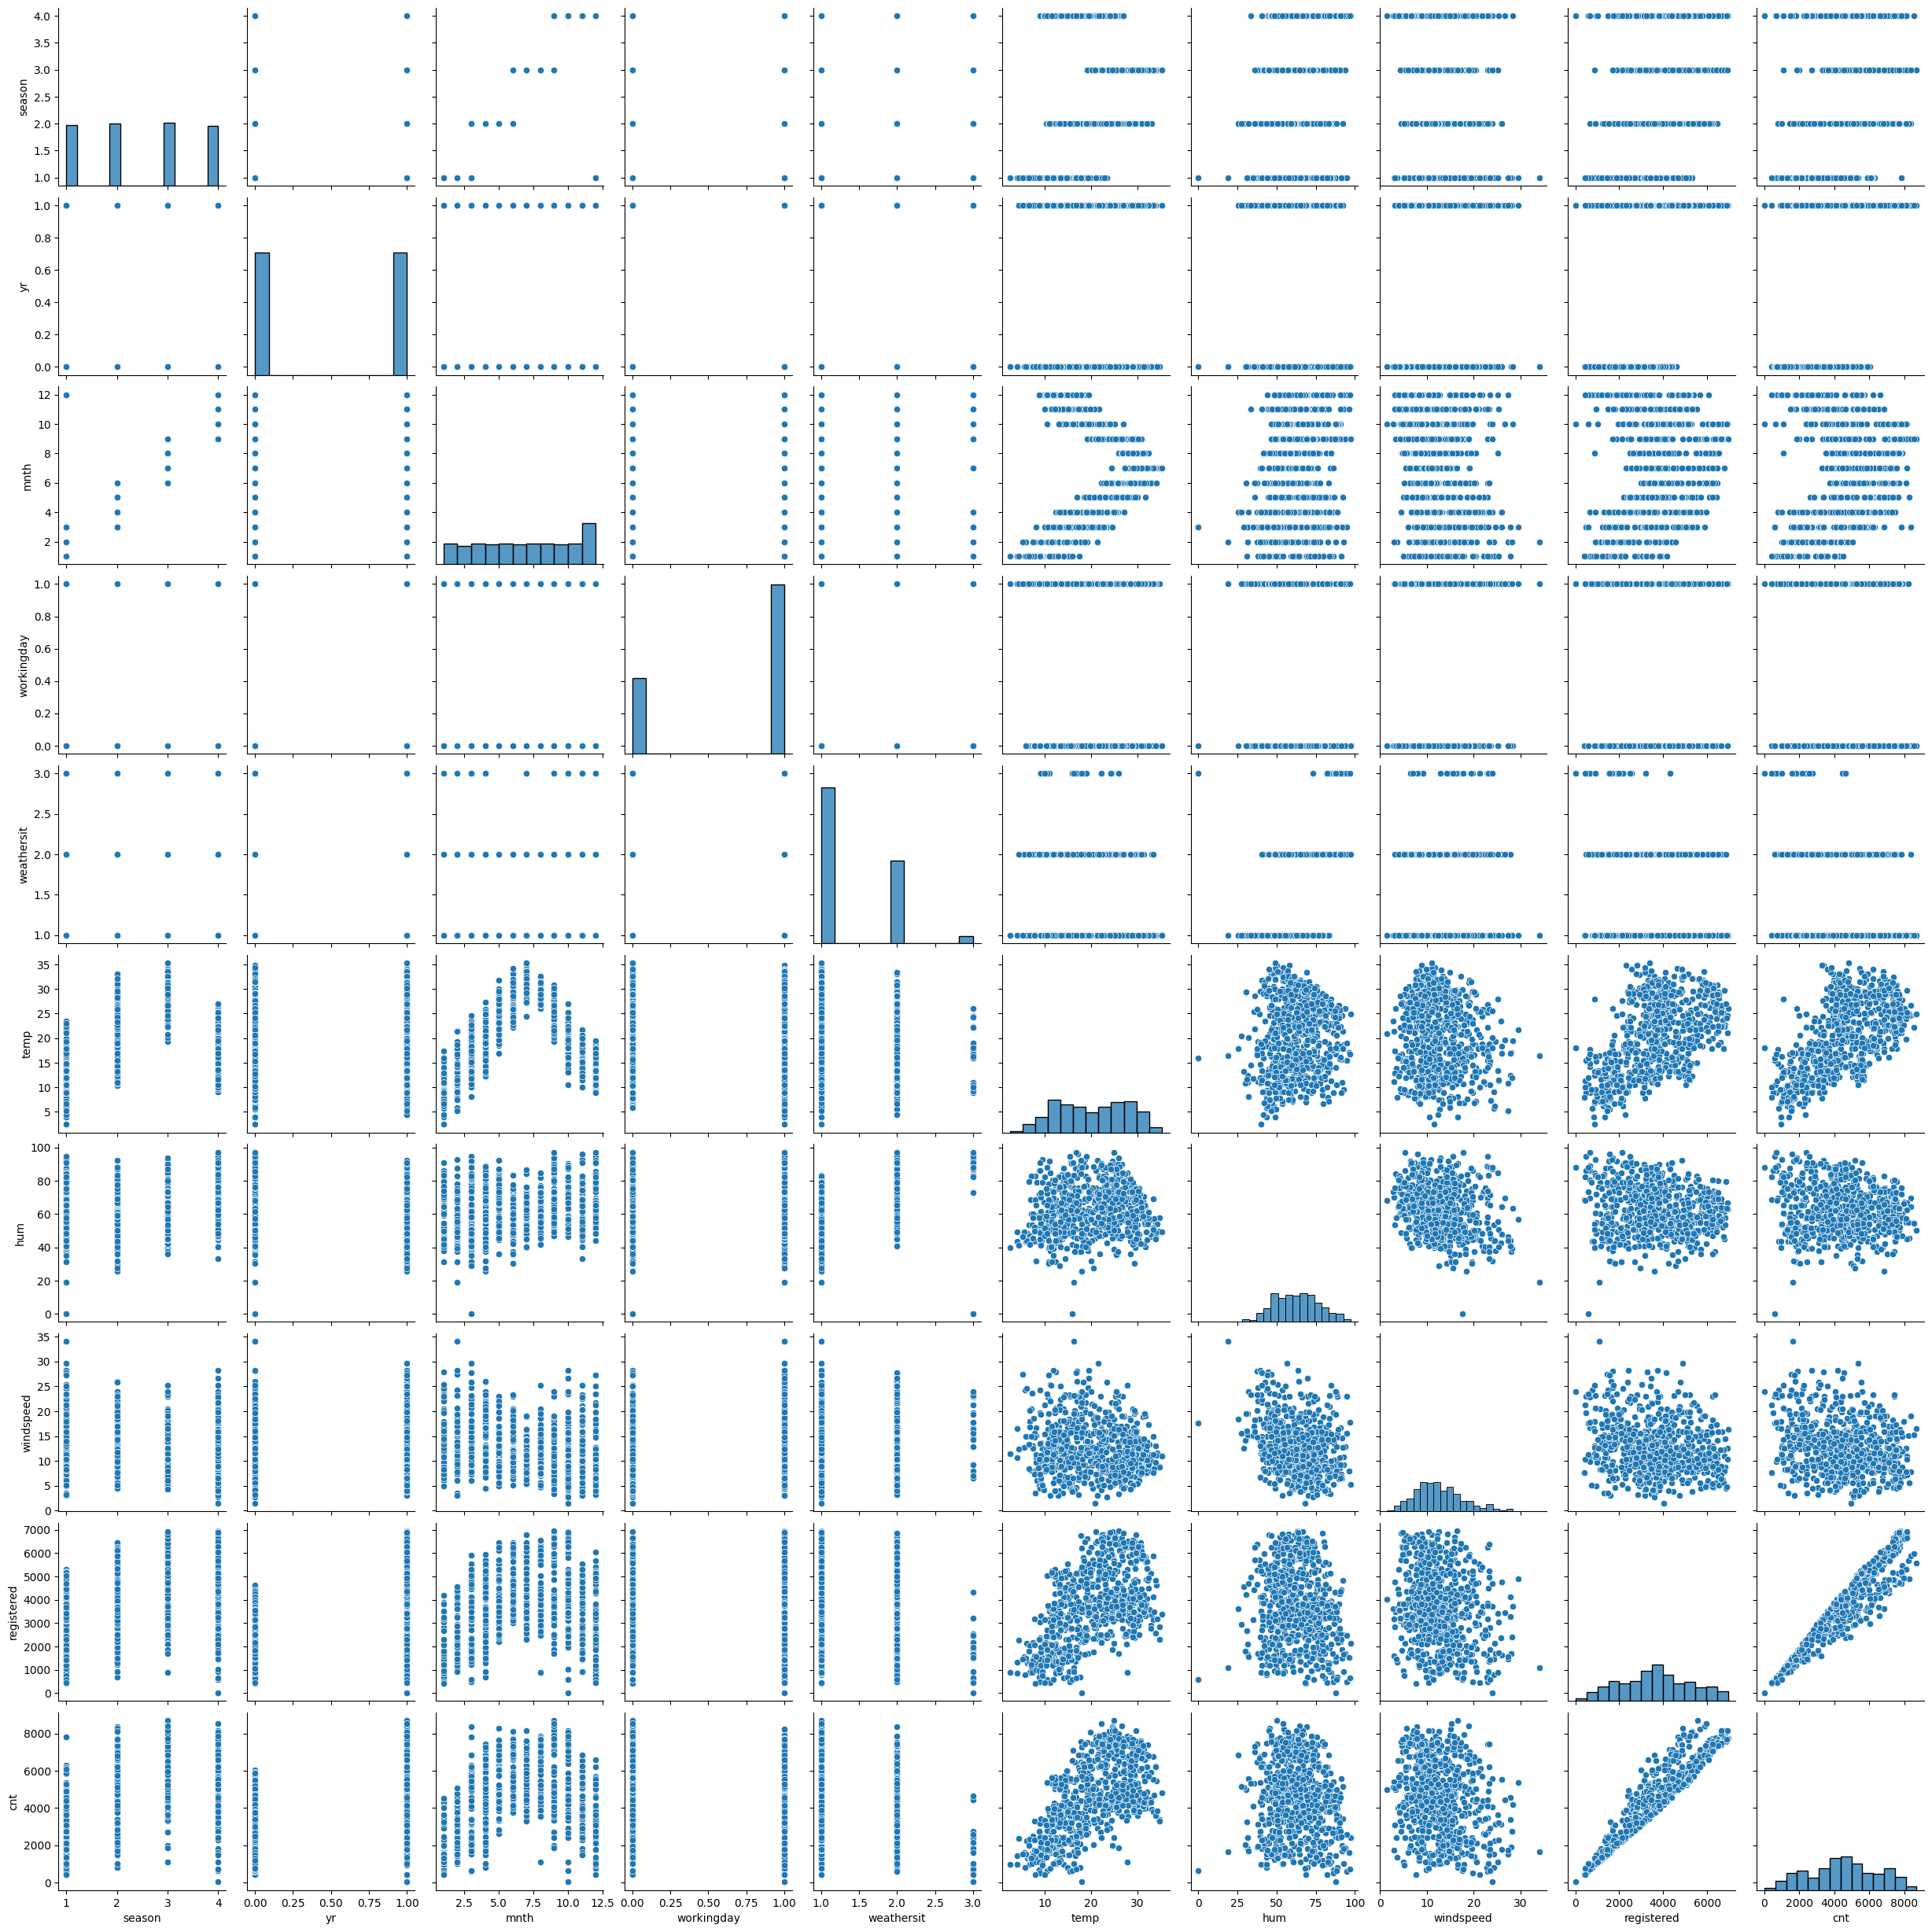

In [20]:
sns.pairplot(df)
#insights -
#1) There are more bikes rented in 2019 than 2018
#2) More bikes are rented in summer and winter than fall and spring. Fall is most favourable for renting
#3) No Bikes are  rented in rainy season (4). Very few on light rains. Most are rented on clear or cloudy days.
#4) Registered users are renting more bikes on week days than casual users.
#4)temp and atemp might show linear relationship. hum and windspeed ?




<Axes: xlabel='weathersit', ylabel='cnt'>

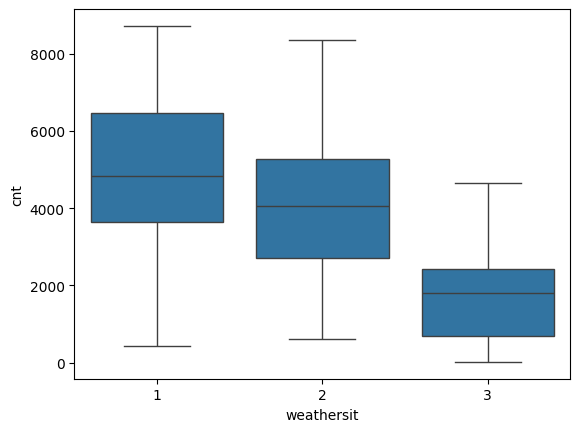

In [21]:

#sns.boxplot(x = 'season', y = 'cnt', hue = 'workingday', data = df )
#There are outliers on working day in fall season

sns.boxplot(x = 'weathersit', y = 'cnt', data = df )

In [23]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df, train_size=0.8, random_state=101)
display(df_train.shape)
display(df_test.shape)


(584, 10)

(146, 10)

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
numerical=['temp','hum','windspeed','cnt']
df_train[numerical] = scaler.fit_transform(df_train[numerical])
df_train.head()

,season,yr,mnth,workingday,weathersit,temp,hum,windspeed,registered,cnt
23,1,0,1,1,1,0.047675,0.388271,0.280244,0.189142,0.163366
527,2,1,6,1,2,0.740406,0.824813,0.396136,0.646116,0.580101
257,3,0,9,0,2,0.645914,0.666134,0.512820,0.463615,0.426228
18,1,0,1,1,2,0.290384,0.707760,0.383295,0.224083,0.190789
148,2,0,5,1,1,0.758058,0.806176,0.394883,0.348397,0.558537


In [25]:
df_train.describe()

,season,yr,mnth,workingday,weathersit,temp,hum,windspeed,registered,cnt
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,2.474315,0.503425,6.410959,0.693493,1.383562,0.543924,0.559569,0.340796,0.524355,0.524580
std,1.104811,0.500417,3.437102,0.461438,0.540126,0.229266,0.180387,0.160739,0.223535,0.225580
min,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,0.000000,1.000000,0.346603,0.423832,0.226924,0.357710,0.373784
50%,2.000000,1.000000,6.000000,1.000000,1.000000,0.540519,0.558573,0.315395,0.529382,0.530470
75%,3.000000,1.000000,9.000000,1.000000,2.000000,0.744819,0.691294,0.430268,0.681598,0.688562
max,4.000000,1.000000,12.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

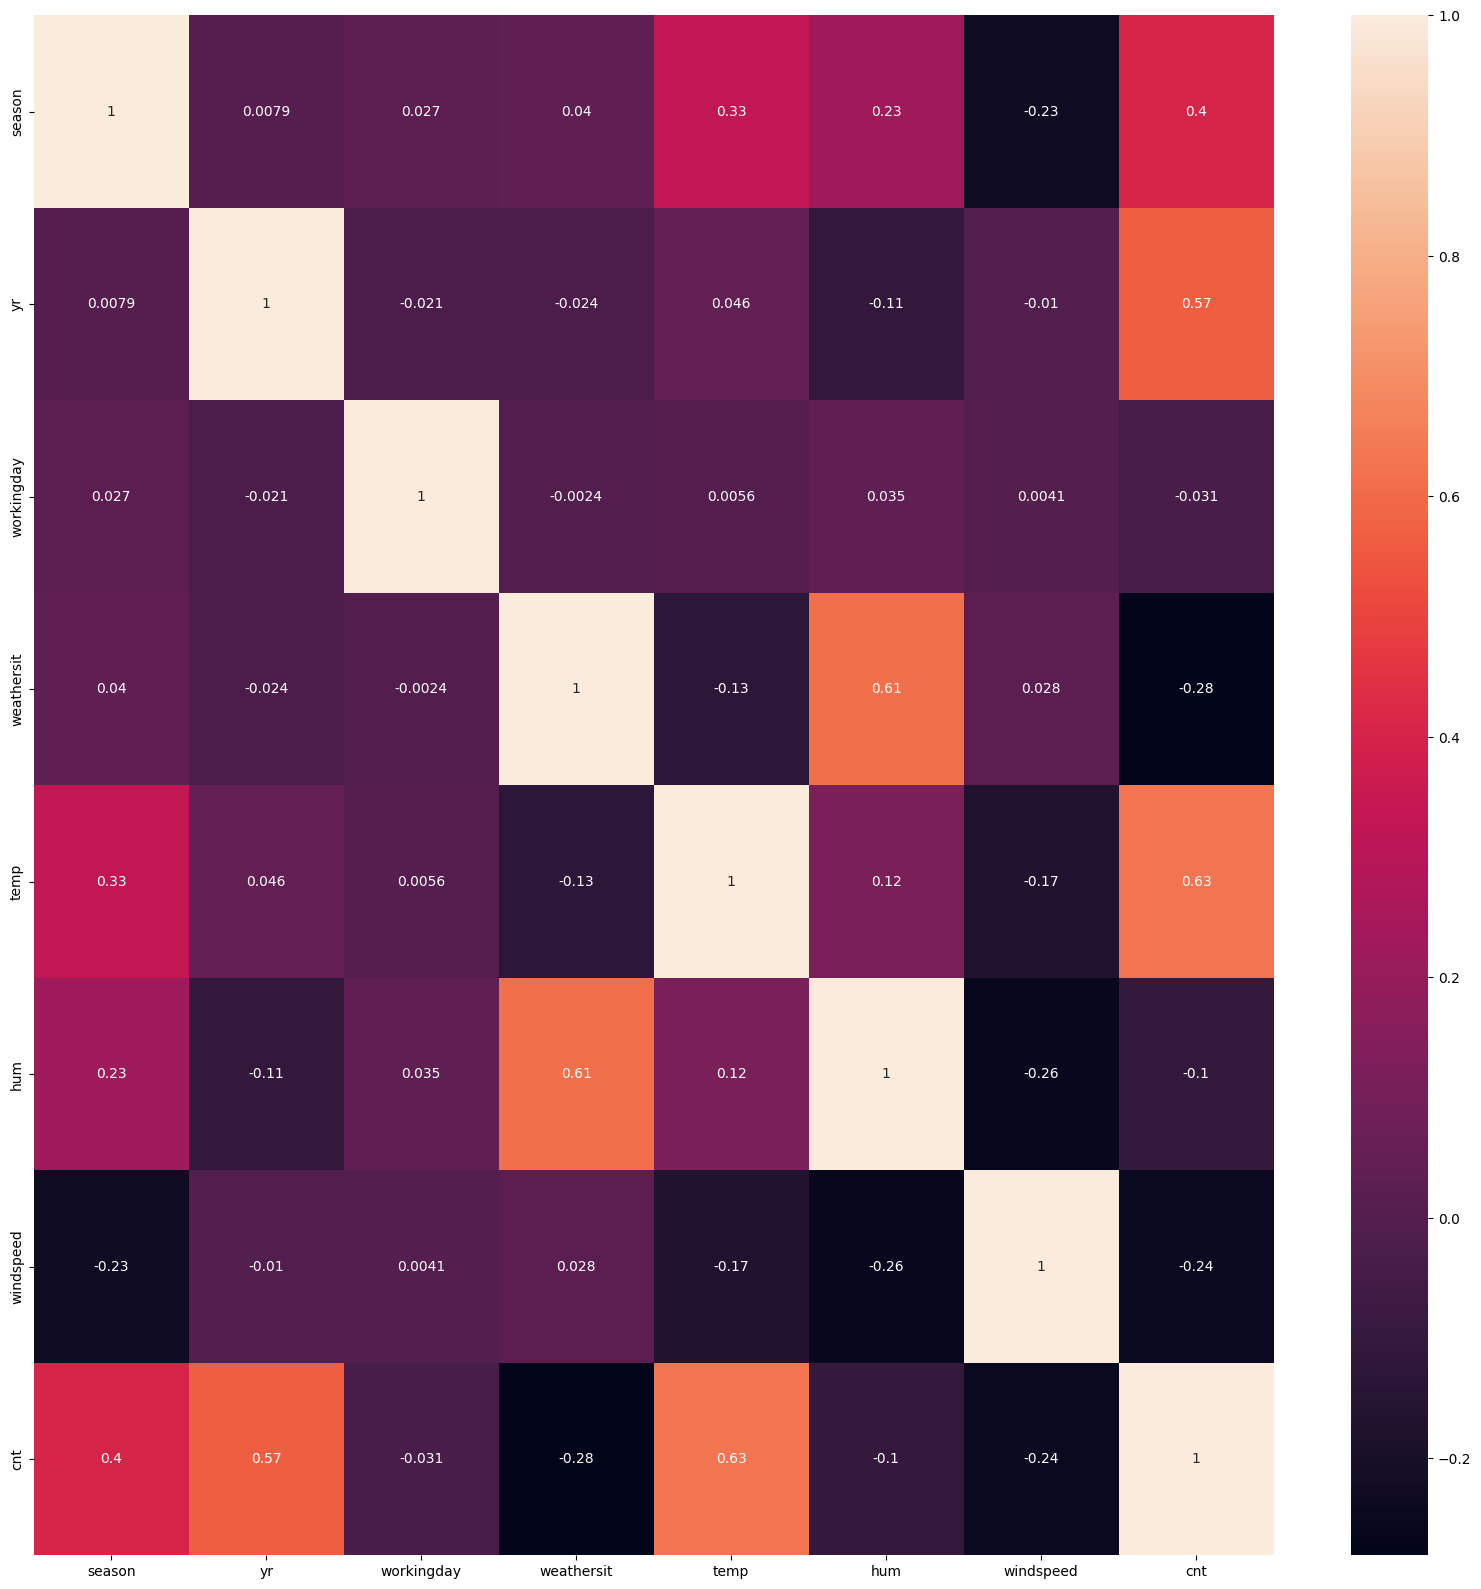

In [28]:
### heatmaps to check correlation, multi collinearity

plt.figure(figsize = (20,20))
#df_train.drop(['registered'], axis = 1, inplace = True )
#df_train.drop(['mnth'], axis = 1, inplace = True )
sns.heatmap(df_train.corr(), annot = True)

In [29]:
y_train = df_train.pop('cnt')
x_train = df_train
y_train.head()

,cnt
23,0.163366
527,0.580101
257,0.426228
18,0.190789
148,0.558537


In [30]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      584 non-null    int64  
 1   yr          584 non-null    int64  
 2   workingday  584 non-null    int64  
 3   weathersit  584 non-null    int64  
 4   temp        584 non-null    float64
 5   hum         584 non-null    float64
 6   windspeed   584 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 36.5 KB


In [31]:
x_train = x_train.apply(pd.to_numeric, errors = 'coerce')
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      584 non-null    int64  
 1   yr          584 non-null    int64  
 2   workingday  584 non-null    int64  
 3   weathersit  584 non-null    int64  
 4   temp        584 non-null    float64
 5   hum         584 non-null    float64
 6   windspeed   584 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 36.5 KB


In [32]:
y_train = y_train.apply(pd.to_numeric, errors = 'coerce')
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 23 to 523
Series name: cnt
Non-Null Count  Dtype  
--------------  -----  
584 non-null    float64
dtypes: float64(1)
memory usage: 9.1 KB


In [33]:
import statsmodels.api as sm


In [34]:
x_train.columns

Index(['season', 'yr', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed'], dtype='object')

In [35]:
x_train = sm.add_constant(x_train)

In [36]:
x_train.head()

,const,season,yr,workingday,weathersit,temp,hum,windspeed
23,1.0,1,0,1,1,0.047675,0.388271,0.280244
527,1.0,2,1,1,2,0.740406,0.824813,0.396136
257,1.0,3,0,0,2,0.645914,0.666134,0.512820
18,1.0,1,0,1,2,0.290384,0.707760,0.383295
148,1.0,2,0,1,1,0.758058,0.806176,0.394883


In [37]:
lr = sm.OLS(y_train, x_train).fit()

In [38]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     305.9
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          2.25e-189
Time:                        06:31:27   Log-Likelihood:                 494.43
No. Observations:                 584   AIC:                            -972.9
Df Residuals:                     576   BIC:                            -937.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2436      0.025      9.943      0.0

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,32.12
6,hum,1.99
4,weathersit,1.82
1,season,1.20
5,temp,1.20
7,windspeed,1.17
2,yr,1.02
3,workingday,1.00


In [40]:
y_train_pred  = lr.predict(x_train)

/tmp/ipykernel_3349/3196132335.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_train - y_train_pred), bins = 20)


<Axes: ylabel='Density'>

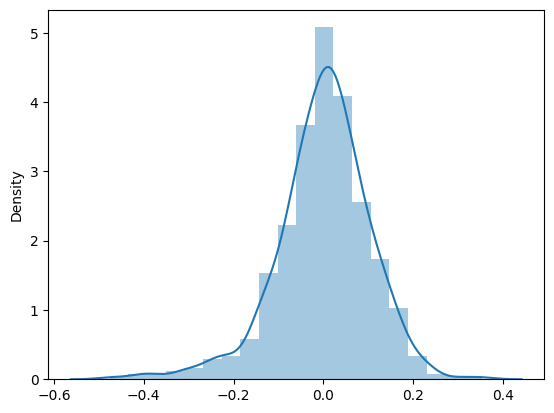

In [41]:
sns.distplot((y_train - y_train_pred), bins = 20)

In [43]:
df_test[numerical] = scaler.transform(df_test[numerical])
#df_test.drop(['registered'], axis = 1, inplace = True )
#df_test.drop(['mnth'], axis = 1, inplace = True )
df_test.describe()

,season,yr,workingday,weathersit,temp,hum,windspeed,cnt
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,2.595890,0.486301,0.678082,1.438356,0.543564,0.571530,0.369657,0.530303
std,1.130021,0.501533,0.468820,0.562906,0.224358,0.188405,0.154753,0.232768
min,1.000000,0.000000,0.000000,1.000000,0.113228,-0.240150,0.063540,0.068323
25%,2.000000,0.000000,0.000000,1.000000,0.340373,0.427449,0.259925,0.357084
50%,3.000000,0.000000,1.000000,1.000000,0.574786,0.569222,0.357688,0.528360
75%,4.000000,1.000000,1.000000,2.000000,0.732099,0.698806,0.453806,0.725653
max,4.000000,1.000000,1.000000,3.000000,0.970925,1.002662,0.751290,1.018634


In [44]:
y_test = df_test.pop('cnt')
x_test = df_test

In [45]:
x_test.head()

,season,yr,workingday,weathersit,temp,hum,windspeed
299,4,0,0,2,0.511964,0.798722,0.361537
723,1,1,0,2,0.289300,0.698870,0.301676
647,4,1,1,1,0.566998,0.566027,0.341041
520,2,1,1,2,0.600225,0.543663,0.385888
114,2,0,1,1,0.682257,0.752396,0.335912


In [46]:
x_test = sm.add_constant(x_test)

/tmp/ipykernel_3349/1319908511.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - y_test_pred), bins = 20)


<Axes: ylabel='Density'>

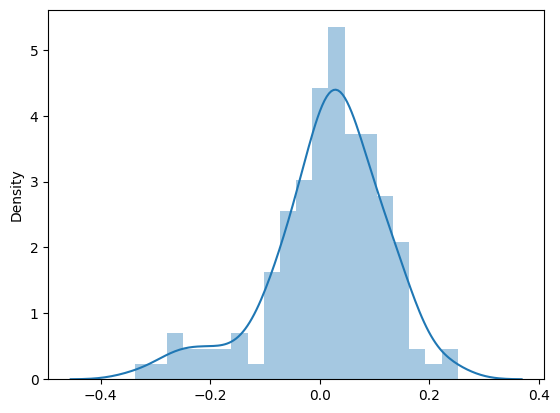

In [47]:
y_test_pred = lr. predict(x_test)

sns.distplot((y_test - y_test_pred), bins = 20)

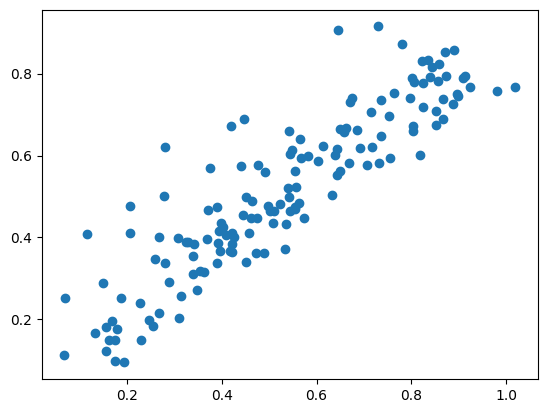

In [48]:
plt.scatter(y_test, y_test_pred)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse

np.float64(0.10569598832642484)

In [52]:
r2_score(y_test, y_test_pred)

0.7923858608236795

/tmp/ipykernel_3349/3956282125.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - y_test_pred), bins = 20 )


<Axes: ylabel='Density'>

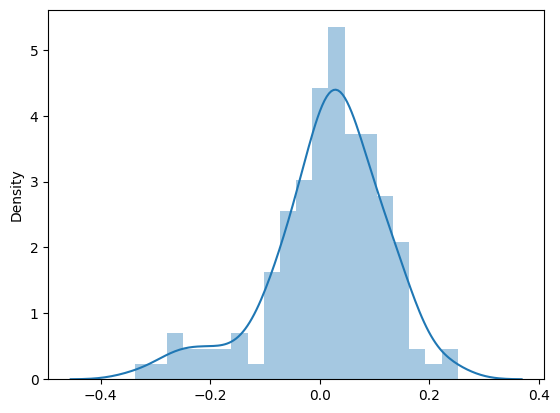

In [54]:
sns.distplot((y_test - y_test_pred), bins = 20 )